In [1]:
## tools

from langchain_community.tools import ArxivQueryRun, WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper, ArxivAPIWrapper


In [2]:
api_wrapper_arxiv = ArxivAPIWrapper(top_k_results=2, doc_content_chars_max=500)
arxiv=ArxivQueryRun(api_wrapper=api_wrapper_arxiv, description="Query arxiv papers")
print(arxiv.name)

arxiv


In [3]:
arxiv.invoke("Attention is all you need")

'Published: 2021-05-06\nTitle: Do You Even Need Attention? A Stack of Feed-Forward Layers Does Surprisingly Well on ImageNet\nAuthors: Luke Melas-Kyriazi\nSummary: The strong performance of vision transformers on image classification and other vision tasks is often attributed to the design of their multi-head attention layers. However, the extent to which attention is responsible for this strong performance remains unclear. In this short report, we ask: is the attention layer even necessary? Specifi'

In [4]:
api_wrapper_wiki= WikipediaAPIWrapper(top_k_results=1, doc_content_chars_max=500)
wiki= WikipediaQueryRun(api_wrapper=api_wrapper_wiki)
wiki.name

'wikipedia'

In [5]:
from dotenv import load_dotenv
load_dotenv()

import os

os.environ['TAVILY_API_KEY']= os.getenv("TAVILY_API_KEY")
os.environ['GROQ_API_KEY']= os.getenv("GROQ_API_KEY")

In [6]:
### Taviliy Search Tool
from langchain_tavily import TavilySearch

tavily = TavilySearch()

In [7]:
tavily.invoke("Provide me the recent AI news?")

{'query': 'Provide me the recent AI news?',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.artificialintelligence-news.com/',
   'title': 'AI News | Latest News | Insights Powering AI-Driven Business Growth',
   'content': 'AI News delivers the latest updates in artificial intelligence, machine learning, deep learning, enterprise AI, and emerging tech worldwide.',
   'score': 0.66464967,
   'raw_content': None},
  {'url': 'https://www.reuters.com/technology/artificial-intelligence/',
   'title': 'AI News | Latest Headlines and Developments | Reuters',
   'content': 'Wild week for AI stocks. AI Weekly: EU targets Grok, Nvidia waves off AI bubble fears. AI Weekly: U.S. and Taiwan make a big AI deal, Grok causes trouble. See',
   'score': 0.644248,
   'raw_content': None},
  {'url': 'https://aimagazine.com/',
   'title': 'AI Magazine: The Latest AI News, Insights and Reports',
   'content': 'The No.1 Magazine, Website, Newsletter & Webinar 

In [8]:
##combine all these tools in the list
tools=[arxiv, wiki, tavily]

In [28]:
## Initialize the LLM Model
from langchain_groq import ChatGroq

llm= ChatGroq(
    model="openai/gpt-oss-120b"
)

In [29]:
llm.invoke("What is AI")

AIMessage(content='**Artificial Intelligence (AI)** is a branch of computer science that focuses on creating machines and software capable of performing tasks that normally require human intelligence. These tasks include learning, reasoning, problem‑solving, perception, language understanding, and even creativity.\n\n### Core ideas behind AI\n| Concept | What it means |\n|---------|----------------|\n| **Machine Learning (ML)** | Algorithms that improve their performance automatically by learning from data. |\n| **Deep Learning** | A subset of ML that uses multi‑layered neural networks (inspired by the brain) to handle complex patterns such as images, speech, and language. |\n| **Natural Language Processing (NLP)** | Techniques that enable computers to understand, generate, and interact with human language. |\n| **Computer Vision** | Giving machines the ability to interpret visual information (photos, video, etc.). |\n| **Reasoning & Planning** | Systems that can draw logical conclusio

In [34]:
llm_with_tools= llm.bind_tools(tools=tools)

In [35]:
## Execute this call
llm_with_tools.invoke("What is the recent news on AI?")

AIMessage(content='', additional_kwargs={'reasoning_content': 'The user asks: "What is the recent news on AI?" Need to provide recent news. Use tavily_search to get recent AI news. Probably limit to last week or month. Let\'s search.', 'tool_calls': [{'id': 'fc_891dfaa1-dd85-48ab-abe0-ce3448bd7a11', 'function': {'arguments': '{"query":"latest AI news April 2026","search_depth":"advanced","time_range":"week","topic":"news"}', 'name': 'tavily_search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 99, 'prompt_tokens': 405, 'total_tokens': 504, 'completion_time': 0.222178023, 'completion_tokens_details': {'reasoning_tokens': 41}, 'prompt_time': 23.9612963, 'prompt_tokens_details': {'cached_tokens': 256}, 'queue_time': 0.052561603, 'total_time': 24.183474323}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_d29d1d1418', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019d4cd

In [36]:
llm_with_tools.invoke("What is the latest research on quantum computing?")

AIMessage(content='', additional_kwargs={'reasoning_content': 'We need latest research on quantum computing. Should browse. Use tavily_search with query "latest research on quantum computing 2024".', 'tool_calls': [{'id': 'fc_651d3881-5005-474d-9b00-20ba3b505e9d', 'function': {'arguments': '{"query":"latest research on quantum computing 2024","search_depth":"advanced","time_range":"year"}', 'name': 'tavily_search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 80, 'prompt_tokens': 406, 'total_tokens': 486, 'completion_time': 0.17466104, 'completion_tokens_details': {'reasoning_tokens': 28}, 'prompt_time': 7.129285749, 'prompt_tokens_details': {'cached_tokens': 256}, 'queue_time': 0.050234821, 'total_time': 7.303946789}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_8a618bed98', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019d4cdd-cdcf-7d40-bd61-0ffff87c1e46-0', to

In [37]:
llm_with_tools.invoke("What is machine learning?")

AIMessage(content='**Machine learning (ML)** is a sub‑field of artificial intelligence (AI) that focuses on developing algorithms and statistical models that enable computers to **learn patterns, make decisions, or predict outcomes from data without being explicitly programmed for each specific task**.\n\n### Core Idea\n- **Learning from Data:** Instead of hard‑coding rules, an ML system infers a function\u202f\\(f\\) that maps inputs\u202f\\(X\\) to outputs\u202f\\(Y\\) by analyzing examples \\((x_i, y_i)\\) drawn from a dataset.\n- **Generalization:** The goal is for the learned function to perform well on new, unseen data, not just on the training examples.\n\n### Typical Workflow\n1. **Collect & Prepare Data** – Gather relevant examples, clean, label, and split into training/validation/test sets.  \n2. **Choose a Model** – Select an algorithm (e.g., linear regression, decision tree, neural network) that defines the hypothesis space.  \n3. **Train** – Optimize the model’s parameters

## LangGraph Workflow

In [38]:
## State Schema
from typing_extensions import TypedDict
from langchain_core.messages import AnyMessage  ## Human or AI message
from typing import Annotated  ##Labelling
from langgraph.graph.message import add_messages ## Reducers in LangGraph


In [39]:
class State(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]

In [40]:
### Entire Chatbot With LangGraph
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition

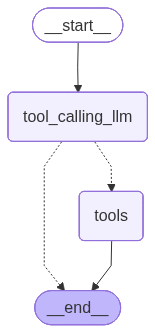

In [41]:
### Node definition
def tool_calling_llm(state:State):
    return {'messages': [llm_with_tools.invoke(state['messages'])]}

## Build Graph
builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

## Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest msg from assistant is tool call -> tools_condition routes to tools
    # If the latest msg from assistant is not tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools", END)

graph = builder.compile()

#View 
display(Image(graph.get_graph().draw_mermaid_png()))




In [42]:
messages= graph.invoke({'messages': "1706.03762"})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

1706.03762
================================== Ai Message ==================================
Tool Calls:
  arxiv (fc_a757db89-b00d-4d7b-9a56-2f14a1025e1f)
 Call ID: fc_a757db89-b00d-4d7b-9a56-2f14a1025e1f
  Args:
    query: 1706.03762
================================= Tool Message =================================
Name: arxiv

Published: 2023-08-02
Title: Attention Is All You Need
Authors: Ashish Vaswani, Noam Shazeer, Niki Parmar, Jakob Uszkoreit, Llion Jones, Aidan N. Gomez, Lukasz Kaiser, Illia Polosukhin
Summary: The dominant sequence transduction models are based on complex recurrent or convolutional neural networks in an encoder-decoder configuration. The best performing models also connect the encoder and decoder through an attention mechanism. We propose a new simple network architecture, the Transformer, base


In [43]:
messages= graph.invoke({'messages': "Hi My name is Sarath"})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Hi My name is Sarath
================================== Ai Message ==================================

Hello Sarath! 👋 Nice to meet you. How can I assist you today?


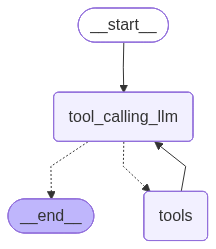

In [44]:
### Node definition
def tool_calling_llm(state:State):
    return {'messages': [llm_with_tools.invoke(state['messages'])]}

## Build Graph
builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

## Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest msg from assistant is tool call -> tools_condition routes to tools
    # If the latest msg from assistant is not tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools", "tool_calling_llm")

graph = builder.compile()

#View 
display(Image(graph.get_graph().draw_mermaid_png()))




In [45]:
messages= graph.invoke({'messages': "Hi My name is Sarath and please tell me the recent research paper on quantum computing"})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Hi My name is Sarath and please tell me the recent research paper on quantum computing
================================== Ai Message ==================================
Tool Calls:
  arxiv (fc_b7b9e47d-29a8-4871-a8ae-310cf68d0347)
 Call ID: fc_b7b9e47d-29a8-4871-a8ae-310cf68d0347
  Args:
    query: quantum computing
================================= Tool Message =================================
Name: arxiv

Published: 2022-11-04
Title: Tierkreis: A Dataflow Framework for Hybrid Quantum-Classical Computing
Authors: Seyon Sivarajah, Lukas Heidemann, Alan Lawrence, Ross Duncan
Summary: We present Tierkreis, a higher-order dataflow graph program representation and runtime designed for compositional, quantum-classical hybrid algorithms. The design of the system is motivated by the remote nature of quantum computers, the need for hybrid algorithms to involve cloud and distributed computing, and the long-
======

In [46]:
messages= graph.invoke({'messages': "What is the recent AI news and then please tell me the recent research paper on quantum computing"})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

What is the recent AI news and then please tell me the recent research paper on quantum computing
================================== Ai Message ==================================
Tool Calls:
  tavily_search (fc_f2a1c55e-3a0f-4c6d-9233-c51590dc8888)
 Call ID: fc_f2a1c55e-3a0f-4c6d-9233-c51590dc8888
  Args:
    query: latest AI news April 2026
    search_depth: advanced
    time_range: month
================================= Tool Message =================================
Name: tavily_search

{"query": "latest AI news April 2026", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://blog.mean.ceo/new-ai-model-releases-news-april-2026/", "title": "New AI Model Releases News | April, 2026 (STARTUP EDITION)", "content": "## AI (artificial intelligence) news, April 2026\n\nThe biggest business news in AI heading into April: OpenAI surpassed $25 billion in annualized revenue and